#Data Cleaning

Data cleaning is the first step in our AI project. Before training the model we need to ensure that the data set is usable. This section names the columns properly, does a way with duplicates, addresses invalid values and drops rows wehre Date is inconsistent(Appointment day is before the ScheduledDay)

Datasetsource: Dataset source: [Medical Appointment No Shows (Kaggle)](https://www.kaggle.com/datasets/joniarroba/noshowappointments)

In [2]:
import pandas as pd


#loading the data and getting description of it
df = pd.read_csv('KaggleV2-May-2016.csv')
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


In [3]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


preview of the data shows there are no null values. AppointmentDay and ScheduledDay give the data type as strings hence needs to be converted to date times so pandas can use. There are negative ages in the preview which need to be cleaned.

In [4]:
#renmaing the columns python standard.
df = df.rename(columns = {
'PatientId' : 'patient_id',
'AppointmentID' : 'appointment_id',
'ScheduledDay': 'scheduled_day',
'AppointmentDay': 'appointment_day',
'Hipertension': 'hypertension',
'Handcap': 'handicap',
'SMS_received':'sms_received',
'No-show': 'no_show',
'Age': 'age',
'Gender': 'gender',
'Neighbourhood': 'neighbourhood'


})

#dropping duplicates
df = df.drop_duplicates()

#removing negative ages.
df = df[df['age'] >= 0]

#converting dates to datime
df['scheduled_day'] = pd.to_datetime(df['scheduled_day'])
df['appointment_day'] = pd.to_datetime(df['appointment_day'])


#subtracting the scheduled day from the appointment day to get the number of days until the appointment.
df['days_until_appointment'] = (pd.to_datetime(df['appointment_day']) -df['scheduled_day']).dt.days

df['days_until_appointment'] = (df['appointment_day'].dt.normalize()
                                - df['scheduled_day'].dt.normalize()).dt.days

df['appointment_day'].dt.day_name()

#MAPPING THE NO SHOW COLUMNS TO 1 AND 0 F0R YES AND NO RESPECTIVELY
df['no_show'] = df['no_show'].map({'Yes':1, 'No':0})

df['gender'] = df['gender'].map({'F':0, 'M':1})

df['appt_weekday'] = df['appointment_day'].dt.day_name()
df = pd.get_dummies(df, columns=['appt_weekday'], drop_first=True)

#dropping features or columns that are not important.
df = df.drop(columns=['patient_id', 'appointment_id', 'scheduled_day', 'appointment_day'])

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   gender                  110526 non-null  int64 
 1   age                     110526 non-null  int64 
 2   neighbourhood           110526 non-null  object
 3   Scholarship             110526 non-null  int64 
 4   hypertension            110526 non-null  int64 
 5   Diabetes                110526 non-null  int64 
 6   Alcoholism              110526 non-null  int64 
 7   handicap                110526 non-null  int64 
 8   sms_received            110526 non-null  int64 
 9   no_show                 110526 non-null  int64 
 10  days_until_appointment  110526 non-null  int64 
 11  appt_weekday_Monday     110526 non-null  bool  
 12  appt_weekday_Saturday   110526 non-null  bool  
 13  appt_weekday_Thursday   110526 non-null  bool  
 14  appt_weekday_Tuesday    110526 non-null  

preview of the data shows there are no null values. AppointmentDay and ScheduledDay give the data type as strings hence needs to be converted to date times so pandas can use. There are negative ages in the preview which need to be cleaned.

In [5]:
# Seperating features and target.
X = df.drop('no_show', axis=1)
y = df['no_show']

print(X.shape)
print(y.shape)


(110526, 15)
(110526,)


In [6]:
#Splitting the dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
# Scaling numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = ['age', 'days_until_appointment']

X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

In [8]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# One-hot encode the 'neighbourhood' column (fixing the case sensitivity error)
X_train_encoded = pd.get_dummies(X_train, columns=['neighbourhood'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['neighbourhood'], drop_first=True)

# Align columns to ensure both train and test sets have the same features
train_cols = X_train_encoded.columns
test_cols = X_test_encoded.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_encoded[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_encoded[c] = 0

# Ensure the order of columns is the same
X_test_encoded = X_test_encoded[train_cols]

model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Use the encoded DataFrames for training
model.fit(X_train_encoded, y_train)

# Making predictions
y_pred = model.predict(X_test_encoded)

In [9]:
# Performance evluation
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

proba = model.predict_proba(X_test_encoded)[:, 1]
print("ROC-AUC  :", roc_auc_score(y_test, proba))
print("PR-AUC   :", average_precision_score(y_test, proba))
print("Baseline :", 1 - y_test.mean())

Accuracy : 0.6562924093006424
Precision: 0.3122903689506469
Recall   : 0.584005376344086
F1 Score : 0.40696222291601625
ROC-AUC  : 0.6700518328695086
PR-AUC   : 0.3068451855469901
Baseline : 0.7980638740613408


In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[11901  5741]
 [ 1857  2607]]


In [11]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.67      0.76     17642
           1       0.31      0.58      0.41      4464

    accuracy                           0.66     22106
   macro avg       0.59      0.63      0.58     22106
weighted avg       0.75      0.66      0.69     22106



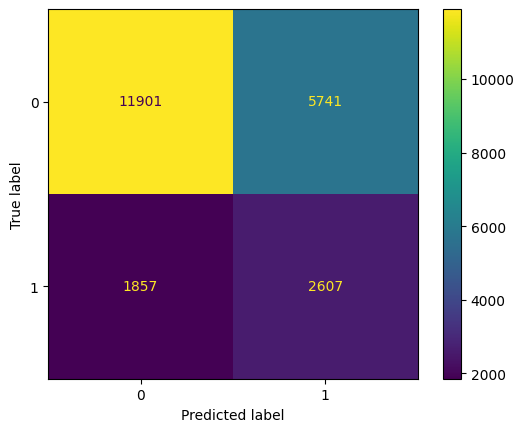

In [12]:
# Plotting the confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test_encoded, y_test)

plt.show()

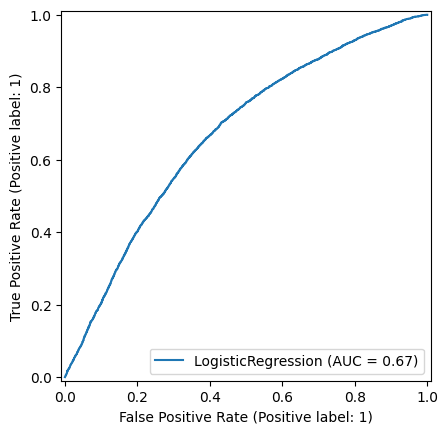

In [13]:
# Plotting the ROC Curve
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(model, X_test_encoded, y_test)

plt.show()

In [14]:
import joblib

##code to save the model to a file.
joblib.dump(model, 'model.pkl')

##saving the scaler as well.
joblib.dump(scaler, 'scaler.pkl')  # Save the scaler as well

#saving the encoded columns
joblib.dump(X_train_encoded.columns, 'feature_columns.pkl')  # Save the model columns for future use


['feature_columns.pkl']